In [83]:
import pandas as pd
from sklearn.model_selection import train_test_split
import itertools
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np
import itertools 

import sys

sys.path.append('functions')  # Make functions/FuncionesMineria.py importable
# Cargo las funciones que voy a utilizar
from FuncionesMineria import  (glm, glm_forward, glm_backward, glm_stepwise, validacion_cruzada_glm,
                           crear_data_modelo, summary_glm, graficoVcramer, impVariablesLog, pseudoR2, 
                           sensEspCorte, curva_roc)



In [69]:
datos = pd.read_pickle('data_clean/datosEleccionesDep.pickle')

varObjBin = datos['AbstencionAlta']
datos_input = datos.drop(['AbstentionPtge',"AbstencionAlta"], axis = 1)

#Nombres de las columnas
var_cont = datos_input.select_dtypes(include=['int64', 'float64', "int32", "float32"]).columns.tolist()
var_categ = datos_input.select_dtypes(include=['object']).columns.tolist()



In [70]:
# Hago la particion
x_train, x_test, y_train, y_test = train_test_split(datos_input, varObjBin, test_size = 0.2)#, random_state = 1234567)
# Indico que la variable respuesta es numérica (hay que introducirla en el algoritmo de phython tal y como la va a tratar)
y_train, y_test = y_train.astype(int), y_test.astype(int)

Selección de variables clásica sin interacciones

In [4]:
modeloStepAIC = glm_stepwise(y_train, x_train, var_cont, var_categ, [], 'AIC')
modeloBackAIC = glm_backward(y_train, x_train,  var_cont, var_categ, [], 'AIC')
modeloFrontAIC = glm_forward(y_train, x_train, var_cont, var_categ, [], 'AIC')
modeloStepBIC = glm_stepwise(y_train, x_train,  var_cont, var_categ, [], 'BIC')
modeloBackBIC = glm_backward(y_train, x_train, var_cont, var_categ, [], 'BIC')
modeloFrontBIC = glm_forward(y_train, x_train, var_cont, var_categ, [], 'BIC')

Start: AIC = 8043.914295383171

y ~ 1

                       Variable         AIC
              + CodigoProvincia 5997.243431
                         + CCAA 6283.096079
             + PersonasInmueble 7646.471101
                + ActividadPpal 7666.974615
             + Age_under19_Ptge 7684.147255
                 + Age_0-4_Ptge 7716.726926
               + Age_over65_pct 7770.967703
                     + Densidad 7777.025216
          + WomanPopulationPtge 7918.097622
                + Age_19_65_pct 7948.808256
     + SameComAutonDiffProvPtge 7965.433053
               + ForeignersPtge 7986.408810
                + PobChange_pct 7991.201634
     + IndustryUnemploymentPtge 7993.874895
             + SameComAutonPtge 7999.296110
           + Unemploy25_40_Ptge 8013.143858
                + Explotaciones 8014.586265
     + ServicesUnemploymentPtge 8021.626168
          + UnemployMore40_Ptge 8022.705544
          + ComercTTEHosteleria 8027.547585
                    + Industria 8027.

KeyboardInterrupt: 

In [10]:
x_test_modeloStepAIC = crear_data_modelo(x_test, modeloStepAIC['Variables']['cont'], 
                                                modeloStepAIC['Variables']['categ'], 
                                                modeloStepAIC['Variables']['inter'])


x_test_modeloBackAIC = crear_data_modelo(x_test, modeloBackAIC['Variables']['cont'], 
                                                modeloBackAIC['Variables']['categ'], 
                                                modeloBackAIC['Variables']['inter'])

x_test_modeloStepBIC = crear_data_modelo(x_test, modeloStepBIC['Variables']['cont'], 
                                                modeloStepBIC['Variables']['categ'], 
                                                modeloStepBIC['Variables']['inter'])
x_test_modeloBackBIC = crear_data_modelo(x_test, modeloBackBIC['Variables']['cont'], 
                                                modeloBackBIC['Variables']['categ'], 
                                                modeloBackBIC['Variables']['inter'])

x_test_modeloFrontAIC = crear_data_modelo(x_test, modeloFrontAIC['Variables']['cont'],
                                                modeloFrontAIC['Variables']['categ'],   
                                                modeloFrontAIC['Variables']['inter'])

x_test_modeloFrontBIC = crear_data_modelo(x_test, modeloFrontBIC['Variables']['cont'],
                                                modeloFrontBIC['Variables']['categ'],
                                                modeloFrontBIC['Variables']['inter'])

In [16]:
# Create a comparison table
models = {
    'Stepwise AIC': {'model': modeloStepAIC, 'x_test': x_test_modeloStepAIC},
    'Backward AIC': {'model': modeloBackAIC, 'x_test': x_test_modeloBackAIC}, 
    'Forward AIC': {'model': modeloFrontAIC, 'x_test': x_test_modeloFrontAIC},
    'Stepwise BIC': {'model': modeloStepBIC, 'x_test': x_test_modeloStepBIC},
    'Backward BIC': {'model': modeloBackBIC, 'x_test': x_test_modeloBackBIC},
    'Forward BIC': {'model': modeloFrontBIC, 'x_test': x_test_modeloFrontBIC}
}

# Create DataFrame to store the comparison metrics
comparison = pd.DataFrame(columns=['Pseudo-R2 Train', 'Pseudo-R2 Test', 'Number of Parameters'])

for name, model_dict in models.items():
    model = model_dict['model']
    x_test_model = model_dict['x_test']
    
    # Ensure the test features have the same columns as the training features.
    # This reindexes the test DataFrame to have the same column order as model['X']
    # Missing columns (such as 'ActividadPpal_Construccion') are filled with 0.
    x_test_model = x_test_model.reindex(columns=model['X'].columns, fill_value=0)
    
    pseudor2_train = pseudoR2(model['Modelo'], model['X'], y_train)
    pseudor2_test  = pseudoR2(model['Modelo'], x_test_model, y_test)
    n_params = len(model['Modelo'].coef_[0])
    auc = curva_roc(model['Modelo'], y_test, x_test_model)
    
    comparison.loc[name] = [pseudor2_train, pseudor2_test, auc, n_params]

# Format the pseudo-R2 columns to 4 decimals and print the comparison DataFrame
comparison[['Pseudo-R2 Train', 'Pseudo-R2 Test']] = comparison[['Pseudo-R2 Train', 'Pseudo-R2 Test']].round(4)
print(comparison)



Optimization terminated successfully.
         Current function value: 0.619122
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.623730
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.619122
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.623730
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.619122
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.623730
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.619122
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.623730
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.619122
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.623730
  

Selección aleatoria de variables

In [8]:

## Seleccion aleatoria (se coge la submuestra de los datos de entrenamiento)

# Inicializar un diccionario para almacenar las fórmulas y variables seleccionadas.
variables_seleccionadas = {
    'Formula': [],
    'Variables': [],
    'Interaccion': []
}

# Realizar 20 iteraciones de selección aleatoria. (en clase no se puede correr con 20)
for x in range(20):
    print('---------------------------- iter: ' + str(x))
    
    # Dividir los datos de entrenamiento en conjuntos de entrenamiento y prueba.
    x_train2, x_test2, y_train2, y_test2 = train_test_split(x_train, y_train, 
                                                            test_size = 0.3, random_state = 1234567 + x)
    
    # Realizar la selección stepwise utilizando el criterio BIC en la submuestra.
    #modelo = glm_stepwise(y_train2.astype(int), x_train2, var_cont, var_categ, interacciones_varcont, 'BIC')
    modelo = glm_stepwise(y_train2.astype(int), x_train2, var_cont, var_categ, [], 'BIC')

    # Almacenar las variables seleccionadas y la fórmula correspondiente.
    variables_seleccionadas['Variables'].append(modelo['Variables'])
    variables_seleccionadas['Formula'].append(sorted(modelo['X'].columns))
# Unir las variables en las fórmulas seleccionadas en una sola cadena.
variables_seleccionadas['Formula'] = list(map(lambda x: '+'.join(x), variables_seleccionadas['Formula']))
    
# Calcular la frecuencia de cada fórmula y ordenarlas por frecuencia.
frecuencias = Counter(variables_seleccionadas['Formula'])
frec_ordenada = pd.DataFrame(list(frecuencias.items()), columns = ['Formula', 'Frecuencia'])
frec_ordenada = frec_ordenada.sort_values('Frecuencia', ascending = False).reset_index()

# Identificar las tres fórmulas más frecuentes y las variables correspondientes.
var_1 = variables_seleccionadas['Variables'][variables_seleccionadas['Formula'].index(
    frec_ordenada['Formula'][0])]
var_2 = variables_seleccionadas['Variables'][variables_seleccionadas['Formula'].index(
    frec_ordenada['Formula'][1])]
var_3 = variables_seleccionadas['Variables'][variables_seleccionadas['Formula'].index(
    frec_ordenada['Formula'][2])]

---------------------------- iter: 0
Start: BIC = 5610.492285600738

y ~ 1

                       Variable         BIC
              + CodigoProvincia 4160.899273
                         + CCAA 4351.536190
                + ActividadPpal 5310.663620
             + PersonasInmueble 5319.779437
             + Age_under19_Ptge 5332.974721
                 + Age_0-4_Ptge 5373.381270
               + Age_over65_pct 5406.081833
                     + Densidad 5406.655182
          + WomanPopulationPtge 5506.532571
                + Age_19_65_pct 5548.900803
               + ForeignersPtge 5551.532114
     + SameComAutonDiffProvPtge 5551.568090
             + SameComAutonPtge 5575.630002
                + PobChange_pct 5575.837887
     + IndustryUnemploymentPtge 5582.623275
                + Explotaciones 5586.109307
           + Unemploy25_40_Ptge 5587.579850
          + UnemployMore40_Ptge 5593.547956
     + ServicesUnemploymentPtge 5593.559758
 + ConstructionUnemploymentPtge 5599.758987


In [9]:

# Imprimir las variables de las tres fórmulas más frecuentes
print("Variables de la fórmula 1:", var_1)
print("Variables de la fórmula 2:", var_2)
print("Variables de la fórmula 3:", var_3)

Variables de la fórmula 1: {'cont': ['SameComAutonPtge', 'Age_over65_pct', 'SUPERFICIE', 'Explotaciones'], 'categ': ['CodigoProvincia', 'ActividadPpal', 'Densidad', 'CCAA'], 'inter': []}
Variables de la fórmula 2: {'cont': ['SameComAutonPtge', 'Age_over65_pct', 'Explotaciones'], 'categ': ['CodigoProvincia', 'ActividadPpal', 'Densidad', 'CCAA'], 'inter': []}
Variables de la fórmula 3: {'cont': ['SameComAutonPtge', 'Age_19_65_pct', 'Explotaciones', 'WomanPopulationPtge', 'PobChange_pct'], 'categ': ['CodigoProvincia', 'ActividadPpal', 'CCAA', 'Densidad'], 'inter': []}


Comparación final de los modelos ganadores de cada método de selección: 

Volver a ejecutar el ganador de la selección clásica porque se cerró VScode

In [10]:
modeloStepBIC = glm_stepwise(y_train, x_train,  var_cont, var_categ, [], 'BIC')

Start: BIC = 8057.471255288187

y ~ 1

                       Variable         BIC
              + CodigoProvincia 6010.800391
                         + CCAA 6296.653039
             + PersonasInmueble 7660.028061
                + ActividadPpal 7680.531574
             + Age_under19_Ptge 7697.704215
                 + Age_0-4_Ptge 7730.283885
               + Age_over65_pct 7784.524663
                     + Densidad 7790.582176
          + WomanPopulationPtge 7931.654582
                + Age_19_65_pct 7962.365216
     + SameComAutonDiffProvPtge 7978.990013
               + ForeignersPtge 7999.965770
                + PobChange_pct 8004.758594
     + IndustryUnemploymentPtge 8007.431854
             + SameComAutonPtge 8012.853069
           + Unemploy25_40_Ptge 8026.700818
                + Explotaciones 8028.143225
     + ServicesUnemploymentPtge 8035.183128
          + UnemployMore40_Ptge 8036.262504
          + ComercTTEHosteleria 8041.104545
                    + Industria 8041.

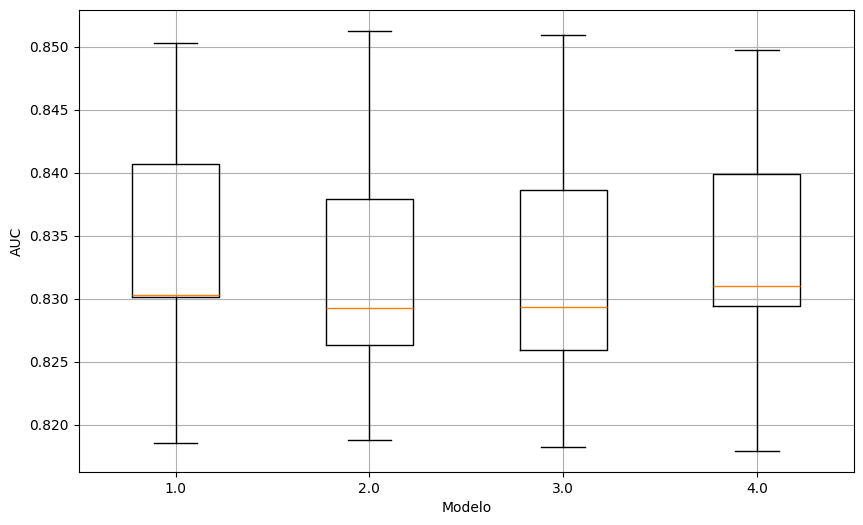

In [95]:
results2 = pd.DataFrame({
    'Rsquared': []
    , 'Resample': []
    , 'Modelo': []
})
for rep in range(20):
    modelo1 = validacion_cruzada_glm(
        5
        , x_train
        , y_train
        , modeloStepBIC['Variables']['cont']
        , modeloStepBIC['Variables']['categ']
        , modeloStepBIC['Variables']['inter']
    )
    modelo2 = validacion_cruzada_glm(
        5
        , x_train
        , y_train
        , var_1['cont']
        , var_1['categ']
        , var_1['inter']
    )
    modelo3 = validacion_cruzada_glm(
        5
        , x_train
        , y_train
        , var_2['cont']
        , var_2['categ']
        , var_2['inter']
    )
    modelo4 = validacion_cruzada_glm(
        5
        , x_train
        , y_train
        , var_3['cont']
        , var_3['categ']
        , var_3['inter']
    )
    results_rep = pd.DataFrame({
        'AUC': modelo1 + modelo2 + modelo3 + modelo4
        , 'Resample': ['Rep' + str((rep + 1))]*5*4
        , 'Modelo': [1]*5 + [2]*5 + [3]*5 + [4]*5
    })
    results2 = pd.concat([results2, results_rep], axis = 0)
     

# Boxplot de la validacion cruzada 
plt.figure(figsize=(10, 6))  # Crea una figura de tamaño 10x6
plt.grid(True)  # Activa la cuadrícula en el gráficoç
# Agrupa los valores de Rsquared por modelo
grupo_metrica = results2.groupby('Modelo')['AUC']
# Organiza los valores de R-squared por grupo en una lista
boxplot_data = [grupo_metrica.get_group(grupo).tolist() for grupo in grupo_metrica.groups]
# Crea un boxplot con los datos organizados
plt.boxplot(boxplot_data, labels=grupo_metrica.groups.keys())  # Etiqueta los grupos en el boxplot
# Etiqueta los ejes del gráfico
plt.xlabel('Modelo')  # Etiqueta del eje x
plt.ylabel('AUC')  # Etiqueta del eje y
plt.show()  # Muestra el gráfico  

# Calcular la media de las métricas R-squared por modelo
media_AUC2= results2.groupby('Modelo')['AUC'].mean()
# Calcular la desviación estándar de las métricas R-squared por modelo
std_AUC2 = results2.groupby('Modelo')['AUC'].std()
# Contar el número de parámetros en cada modelo
num_params2 = [len(modeloStepBIC['Modelo'].coef_[0]), 
                 len(frec_ordenada['Formula'][0].split('+')),
                 len(frec_ordenada['Formula'][1].split('+')), 
                 len(frec_ordenada['Formula'][2].split('+'))]


In [96]:
# Create DataFrame with metrics
metrics_df = pd.DataFrame({
    'Model': ['StepwiseBIC', 'Random Selection 1', 'Random Selection 2', 'Random Selection 3'],
    'Mean AUC': media_AUC2,
    'Std AUC': std_AUC2,
    'Num Parameters': [len(modeloStepBIC['Modelo'].coef_[0]), 
                      len(frec_ordenada['Formula'][0].split('+')), 
                      len(frec_ordenada['Formula'][1].split('+')),
                      len(frec_ordenada['Formula'][2].split('+'))]
                      
})

# Format floating point numbers
metrics_df['Mean AUC'] = metrics_df['Mean AUC'].round(4)
metrics_df['Std AUC'] = metrics_df['Std AUC'].round(4)

print(metrics_df)

                     Model  Mean AUC  Std AUC  Num Parameters
Modelo                                                       
1.0            StepwiseBIC    0.8340   0.0108              77
2.0     Random Selection 1    0.8327   0.0112              75
3.0     Random Selection 2    0.8326   0.0113              74
4.0     Random Selection 3    0.8336   0.0107              76


Siguiendo el principio de parsimonia, el modelo ganador es el 3. Todos los modelos son muy parecidos, pero este modelo cuenta con el número de parámetros más bajo.

In [71]:
# Variables continuas
var_contGanador = ['SameComAutonPtge', 'Age_over65_pct', 'Explotaciones']

# Variables categóricas
var_categGanador = ['CodigoProvincia', 'ActividadPpal', 'Densidad', 'CCAA']

# Variables de interacción (en este caso, está vacío)
var_interacGanador = []

In [75]:

modeloGanador = glm(y_train, x_train, var_contGanador, var_categGanador)

Ahora que ya tenemos un modelo ganador, hallamos su punto de corte óptimo

In [97]:

## Buscamos el mejor punto de corte
# Probamos dos
sensEspCorte(modeloGanador['Modelo'], x_test, y_test, 0.4, var_contGanador, var_categGanador, var_interacGanador)
sensEspCorte(modeloGanador['Modelo'], x_test, y_test, 0.6, var_contGanador, var_categGanador, var_interacGanador)


# Generamos una rejilla de puntos de corte
posiblesCortes = np.arange(0, 1.01, 0.01).tolist()  # Generamos puntos de corte de 0 a 1 con intervalo de 0.01
rejilla = pd.DataFrame({
    'PtoCorte': [],
    'Accuracy': [],
    'Sensitivity': [],
    'Specificity': [],
    'PosPredValue': [],
    'NegPredValue': []
})  # Creamos un DataFrame para almacenar las métricas para cada punto de corte

for pto_corte in posiblesCortes:  # Iteramos sobre los puntos de corte
    rejilla = pd.concat(
        [rejilla, sensEspCorte(modeloGanador['Modelo'], x_test, y_test, pto_corte, var_contGanador, var_categGanador)],
        axis=0
    )  # Calculamos las métricas para el punto de corte actual y lo agregamos al DataFrame

rejilla['Youden'] = rejilla['Sensitivity'] + rejilla['Specificity'] - 1  # Calculamos el índice de Youden
rejilla.index = list(range(len(rejilla)))  # Reindexamos el DataFrame para que los índices sean consecutivos




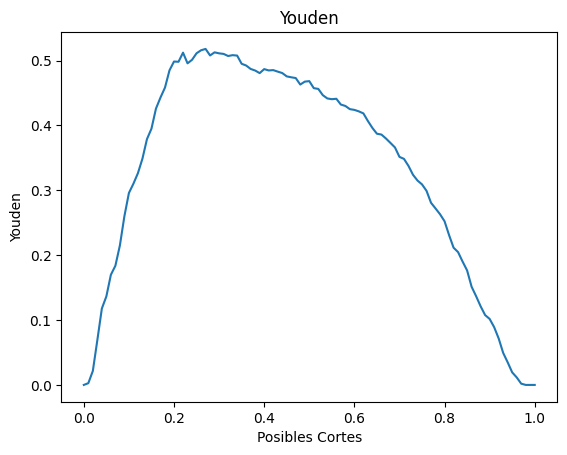

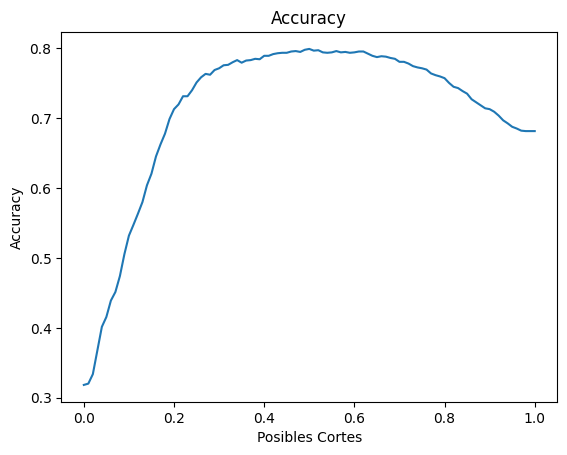

In [98]:

plt.plot(rejilla['PtoCorte'], rejilla['Youden'])
plt.xlabel('Posibles Cortes')
plt.ylabel('Youden')
plt.title('Youden')
plt.show()

plt.plot(rejilla['PtoCorte'], rejilla['Accuracy'])
plt.xlabel('Posibles Cortes')
plt.ylabel('Accuracy')
plt.title('Accuracy')
plt.show()



In [99]:
# Encuentra el punto de corte que maximiza el índice de Youden
pto_corte_youden = rejilla['PtoCorte'][rejilla['Youden'].idxmax()]

# Encuentra el punto de corte que maximiza la precisión (Accuracy)
pto_corte_accuracy = rejilla['PtoCorte'][rejilla['Accuracy'].idxmax()]
print(f"Punto de corte que maximiza el índice de Youden: {pto_corte_youden}")
print(f"Punto de corte que maximiza la precisión (Accuracy): {pto_corte_accuracy}")


Punto de corte que maximiza el índice de Youden: 0.27
Punto de corte que maximiza la precisión (Accuracy): 0.5


In [100]:
# El resultado es 0.27 para youden y 0.5 para Accuracy
# Los comparamos
sensEspCorte(modeloGanador['Modelo'], x_test, y_test, 0.27, var_contGanador, var_categGanador, var_interacGanador)




,PtoCorte,Accuracy,Sensitivity,Specificity,PosPredValue,NegPredValue
0,0.27,0.763547,0.746615,0.771454,0.604069,0.867005


In [101]:
sensEspCorte(modeloGanador['Modelo'], x_test, y_test, 0.5, var_contGanador, var_categGanador, var_interacGanador)   

,PtoCorte,Accuracy,Sensitivity,Specificity,PosPredValue,NegPredValue
0,0.5,0.799261,0.555126,0.913279,0.749347,0.814666


In [109]:
# Vemos los coeficientes del modelo ganador
print(summary_glm(modeloGanador['Modelo'], y_train, modeloGanador['X']))


{'Contrastes':               Variable  Estimate    Std. Error       z value   p value signif
0          (Intercept)  2.263998           NaN           NaN       nan       
1     SameComAutonPtge -0.031890  7.951030e-03 -4.010748e+00  0.000061    ***
2       Age_over65_pct  0.019690  4.149020e-03  4.745591e+00  0.000002    ***
3        Explotaciones  0.000728  1.734879e-04  4.197988e+00  0.000027    ***
4   CodigoProvincia_10 -0.364156  1.544727e+07 -2.357410e-08  1.000000       
..                 ...       ...           ...           ...       ...    ...
70         CCAA_Madrid -0.771688           NaN           NaN       nan       
71         CCAA_Murcia -0.501129           NaN           NaN       nan       
72        CCAA_Navarra  0.338644  4.737199e+07  7.148613e-09  1.000000       
73      CCAA_PaísVasco  0.552695           NaN           NaN       nan       
74          CCAA_Rioja -1.357415  1.424683e+08 -9.527839e-09  1.000000       

[75 rows x 6 columns], 'BondadAjuste':          

Optimization terminated successfully.
         Current function value: 0.618628
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.618628
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.618628
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.618628
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.618628
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.618628
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.618628
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.618628
         Iterations 5
          Variables        R2
6              CCAA  0.001214
2     Explotaciones  0.002633
1    Age_over65_pct  0.002765
5          Densidad  0.003462
4     ActividadPpal  0.006004
0  S

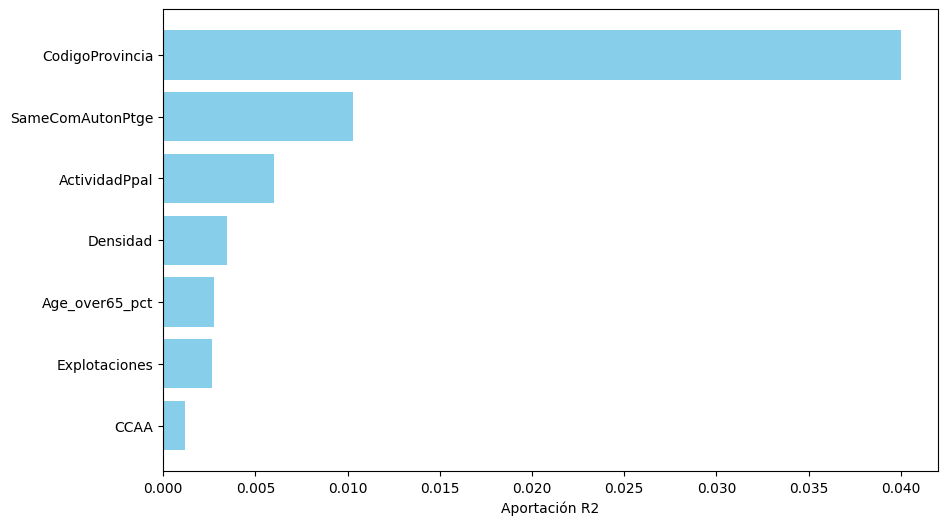

,Variables,R2
6,CCAA,0.001214
2,Explotaciones,0.002633
1,Age_over65_pct,0.002765
5,Densidad,0.003462
4,ActividadPpal,0.006004
0,SameComAutonPtge,0.010293
3,CodigoProvincia,0.040013


In [103]:
impVariablesLog(modeloGanador, y_train, x_train, var_contGanador, var_categGanador)



In [113]:
# Vemos los coeficientes del modelo ganador
coeficientes = modeloGanador['Modelo'].coef_
nombres_caracteristicas = crear_data_modelo(x_train, var_contGanador, var_categGanador).columns  # Suponiendo que X_train es un DataFrame de pandas

# Imprime los nombres de las características junto con sus coeficientes
for nombre, coef in zip(nombres_caracteristicas, coeficientes[0]):
    print(f"Variable: {nombre}, Coeficiente: {coef}")


Variable: SameComAutonPtge, Coeficiente: -0.03188957847113797
Variable: Age_over65_pct, Coeficiente: 0.019689554115921024
Variable: Explotaciones, Coeficiente: 0.0007283001425264559
Variable: CodigoProvincia_10, Coeficiente: -0.3641555064285813
Variable: CodigoProvincia_11, Coeficiente: 1.8207527707489088
Variable: CodigoProvincia_12, Coeficiente: -0.2933872446707822
Variable: CodigoProvincia_13, Coeficiente: 0.030064141752772534
Variable: CodigoProvincia_14, Coeficiente: -0.9589860007620465
Variable: CodigoProvincia_15, Coeficiente: 0.7569093131871175
Variable: CodigoProvincia_16, Coeficiente: -0.45782901140208976
Variable: CodigoProvincia_17, Coeficiente: 0.547375692927095
Variable: CodigoProvincia_18, Coeficiente: 0.1375062761842217
Variable: CodigoProvincia_19, Coeficiente: -0.4329816307611543
Variable: CodigoProvincia_2, Coeficiente: -0.3577275570553644
Variable: CodigoProvincia_20, Coeficiente: 2.267511918275825
Variable: CodigoProvincia_21, Coeficiente: 1.4025369548831776
Variab

In [ ]:

# Evaluamos la estabilidad del modelo a partir de las diferencias en train y test:
pseudoR2(modeloGanador['Modelo'], modeloGanador['X'], y_train)
pseudoR2(modeloGanador['Modelo'], var_categGanador, y_test)
# Es poca la diferencia, por lo que el modelo se puede considerar robusto

# Calculamos la diferencia del Area bajo la curva ROC en train y test
curva_roc(crear_data_modelo(x_train, var_contGanador, var_categGanador), y_train, modeloGanador)
curva_roc(x_test, y_test, modeloGanador)

# Calculamos la diferencia de las medidas de calidad entre train y test 
sensEspCorte(modeloGanador['Modelo'], x_train, y_train, 0.27, var_contGanador, var_categGanador)

Optimization terminated successfully.
         Current function value: 0.618628
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.625619
         Iterations 4


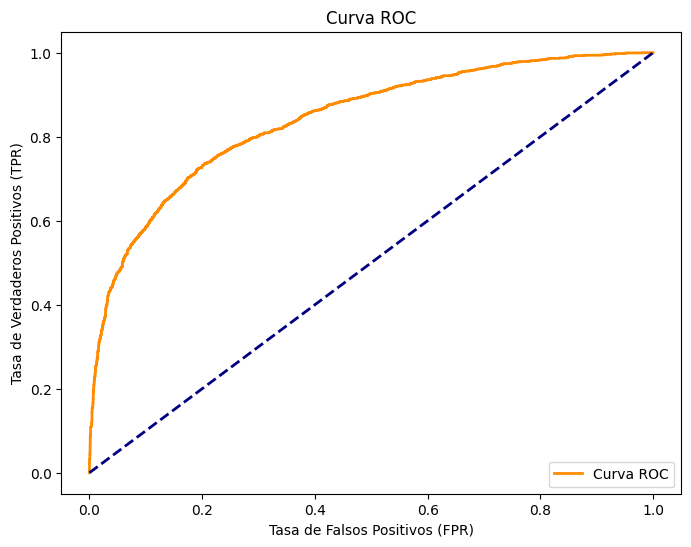

Área bajo la curva ROC = 0.8413265417130497


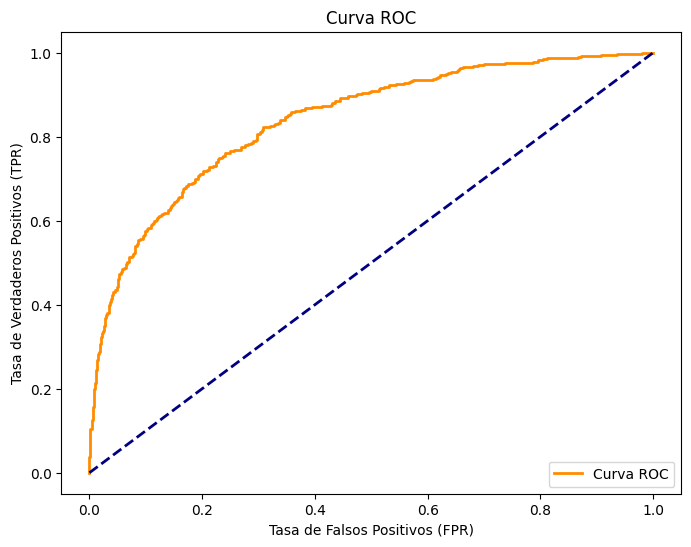

Área bajo la curva ROC = 0.8392172896583898
     Métrica  Entrenamiento      Test
0  Pseudo R2       0.294397  0.284214
1    ROC AUC       0.841327  0.839217


In [119]:

# Calcula el pseudo R2 para entrenamiento y prueba
pseudoR2_train = pseudoR2(modeloGanador['Modelo'], crear_data_modelo(x_train, var_contGanador, var_categGanador), y_train)
pseudoR2_test = pseudoR2(modeloGanador['Modelo'], crear_data_modelo(x_test, var_contGanador, var_categGanador), y_test)

# Calcula el AUC de la curva ROC para entrenamiento y prueba
roc_train = curva_roc(crear_data_modelo(x_train, var_contGanador, var_categGanador), y_train, modeloGanador)
roc_test = curva_roc(crear_data_modelo(x_test, var_contGanador, var_categGanador), y_test, modeloGanador)

# Crear un DataFrame con los resultados
resultados = pd.DataFrame({
    'Métrica': ['Pseudo R2', 'ROC AUC'],
    'Entrenamiento': [pseudoR2_train, roc_train],
    'Test': [pseudoR2_test, roc_test]
})

# Imprimir la tabla
print(resultados)